In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_columns', None)


In [6]:
df = pd.read_csv('../data/raw/GiveMeSomeCredit/cs-training.csv', index_col=0)
print(df.shape)
df.head()

(150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [7]:
print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nClass balance:\n", df['SeriousDlqin2yrs'].value_counts(normalize=True))

Shape: (150000, 11)

Column types:
 SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

Missing values:
 SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines        

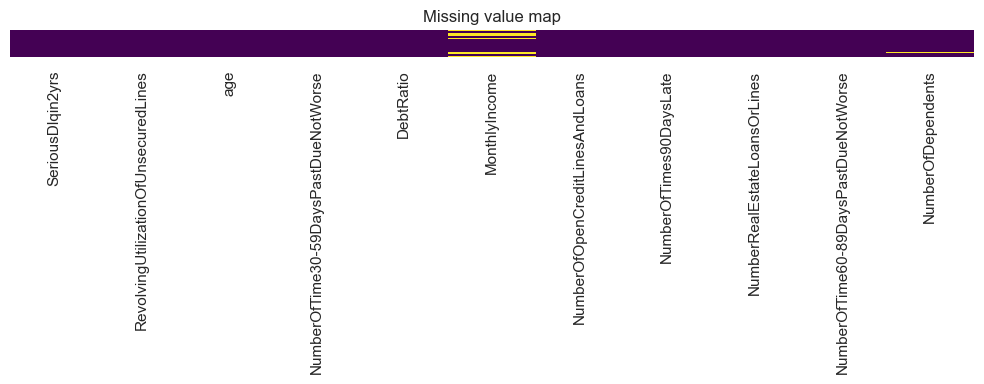

In [8]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing value map')
plt.tight_layout()
plt.savefig('../reports/missing_values.png', dpi=150)
plt.show()

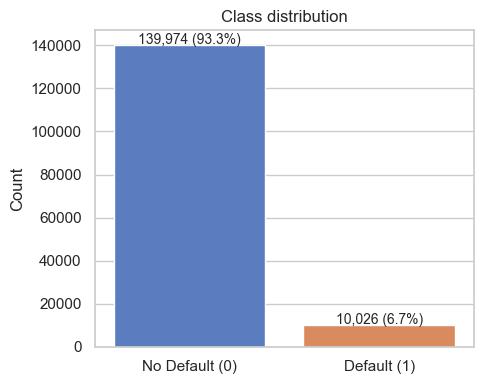

In [9]:
counts = df['SeriousDlqin2yrs'].value_counts()
plt.figure(figsize=(5, 4))
sns.barplot(x=['No Default (0)', 'Default (1)'], y=counts.values, palette='muted')
plt.title('Class distribution')
plt.ylabel('Count')
for i, v in enumerate(counts.values):
    plt.text(i, v + 500, f'{v:,} ({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/class_distribution.png', dpi=150)
plt.show()

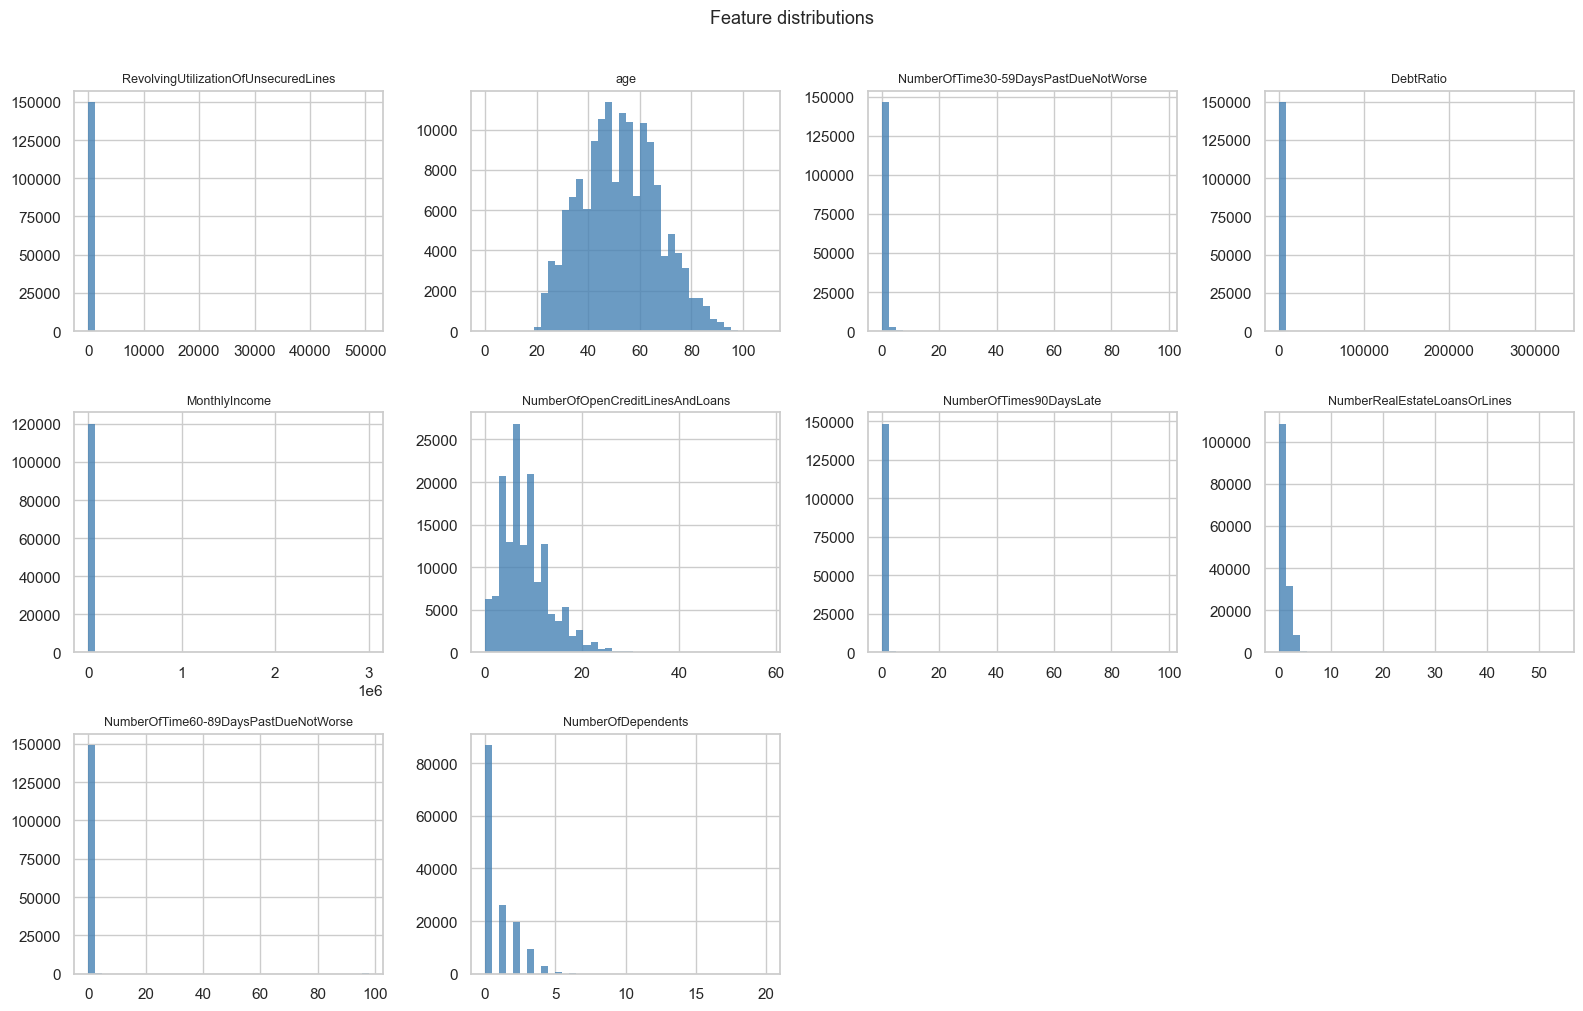

In [10]:
features = [c for c in df.columns if c != 'SeriousDlqin2yrs']
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/feature_distributions.png', dpi=150)
plt.show()

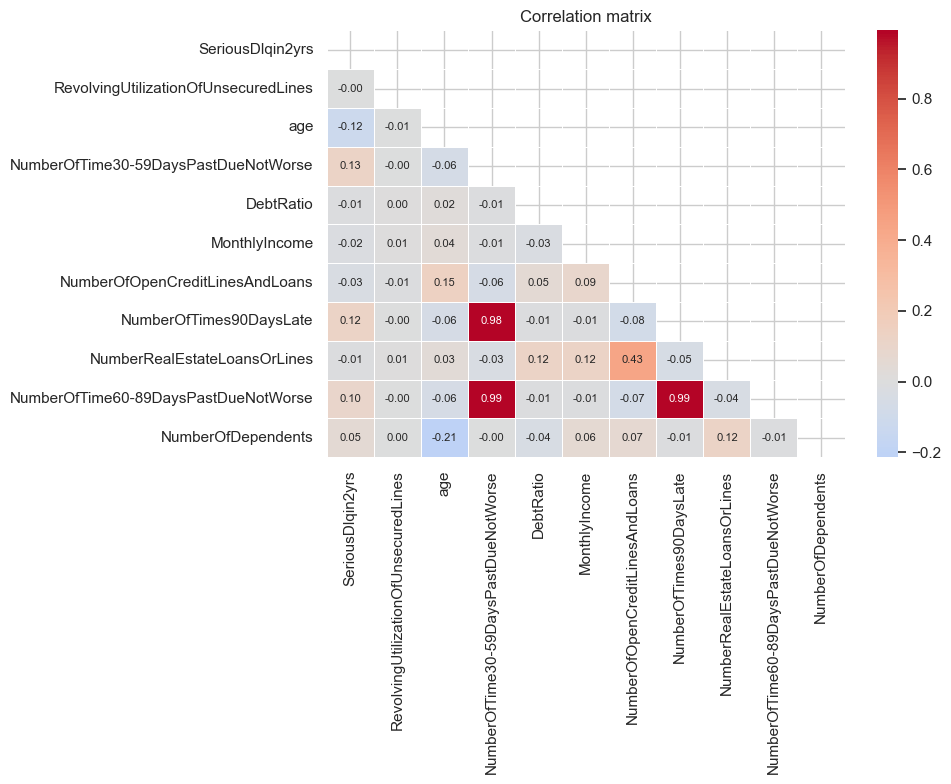

In [11]:
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title('Correlation matrix')
plt.tight_layout()
plt.savefig('../reports/correlation_matrix.png', dpi=150)
plt.show()

In [12]:
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)

print("Missing after imputation:\n", df.isnull().sum())

Missing after imputation:
 SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [13]:
# Clip outliers at 99th percentile
for col in ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']:
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper)

# New features
df['debt_to_income_ratio'] = df['DebtRatio'] * df['MonthlyIncome']
df['total_past_due'] = (df['NumberOfTime30-59DaysPastDueNotWorse'] +
                        df['NumberOfTime60-89DaysPastDueNotWorse'] +
                        df['NumberOfTimes90DaysLate'])
df['credit_util_bucket'] = pd.cut(df['RevolvingUtilizationOfUnsecuredLines'],
                                   bins=[0, 0.3, 0.6, 0.9, float('inf')],
                                   labels=[0, 1, 2, 3]).astype(float)

print("New shape:", df.shape)
df[['debt_to_income_ratio', 'total_past_due', 'credit_util_bucket']].describe()

New shape: (150000, 14)


,debt_to_income_ratio,total_past_due,credit_util_bucket
count,1.500000e+05,150000.000000,139122.000000
mean,1.610357e+06,0.927393,0.808053
std,4.782748e+06,12.466204,1.112927
min,0.000000e+00,0.000000,0.000000
25%,7.726791e+02,0.000000,0.000000
50%,2.100719e+03,0.000000,0.000000
75%,4.761906e+03,0.000000,2.000000
max,2.688682e+07,294.000000,3.000000


In [14]:
df.to_csv('../data/processed/clean.csv', index=False)
print("Saved to data/processed/clean.csv")
print("Final shape:", df.shape)

Saved to data/processed/clean.csv
Final shape: (150000, 14)


In [15]:
df_check = pd.read_csv('../data/processed/clean.csv')
print("Shape:", df_check.shape)
print("Missing values:", df_check.isnull().sum().sum())
print("Columns:", df_check.columns.tolist())
df_check.head(3)

Shape: (150000, 14)
Missing values: 10878
Columns: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'debt_to_income_ratio', 'total_past_due', 'credit_util_bucket']


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,debt_to_income_ratio,total_past_due,credit_util_bucket
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,7323.197016,2,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,316.878123,0,3.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,258.914887,2,2.0
